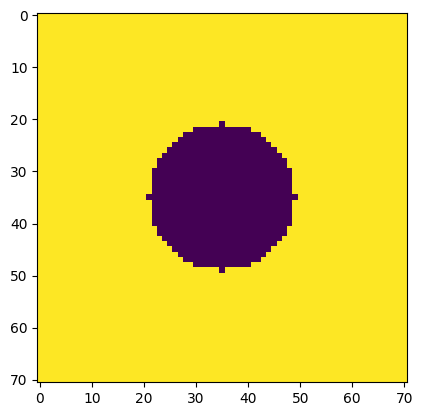

In [3]:
# Constructing a Synthetic Circle Image
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

w, h = 71, 71
hw, hh = w//2, h//2

f = np.ones((h, w), dtype=np.float32)

X, Y = np.meshgrid(np.arange(-hh, hh+1, 1),
                   np.arange(-hw, hw+1, 1))

r = w//5  # radius of the inner circle 14

f *= X**2 + Y**2 > r**2

plt.imshow(f)
plt.show()

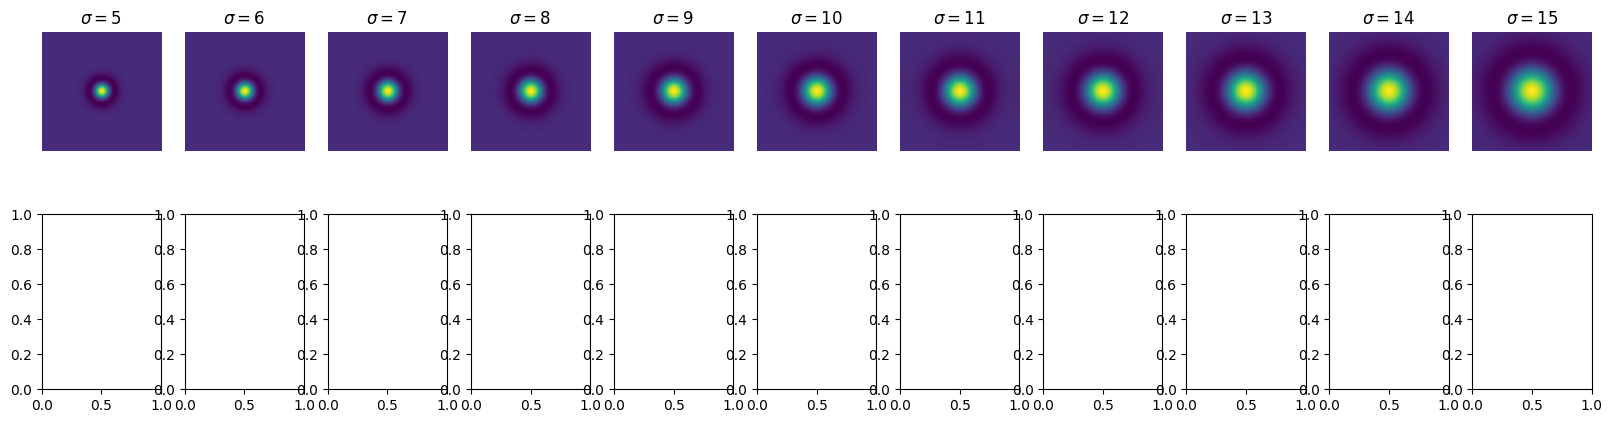

In [4]:
# Convolving the Circle Image with a Scale-Normalized Laplacian of Gaussian
s = 11  # No. of scales
fig, ax = plt.subplots(2, s, figsize=(20, 5))

scale_space = np.empty((h, w, s), dtype=np.float32)

sigmas = np.arange(5, 5 + s, 1)
log_hw = 3*np.max(sigmas)

for i, sigma in enumerate(sigmas):

    X, Y = np.meshgrid(np.arange(-log_hw, log_hw+1, 1),
                       np.arange(-log_hw, log_hw+1, 1))

    log = -1/(2*np.pi*sigma**2) * ((X**2 + Y**2 - 2*sigma**2) / (sigma**2)) * \
          np.exp(-(X**2 + Y**2) / (2*sigma**2))

    f_log = cv.filter2D(f, -1, log)

    scale_space[:, :, i] = f_log

    ax[0, i].imshow(log)
    ax[0, i].axis('off')
    ax[0, i].set_title(r'$\sigma = {}$'.format(sigma))

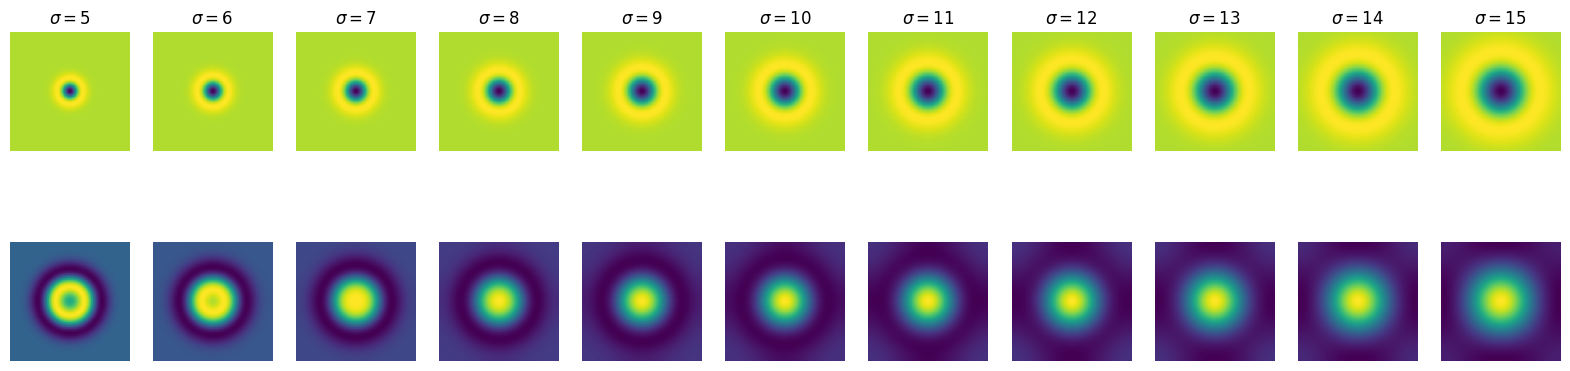

In [6]:
# Convolving the Circle Image with a Scale-Normalized Laplacian of Gaussian
s = 11  # No. of scales
fig, ax = plt.subplots(2, s, figsize=(20, 5))

scale_space = np.empty((h, w, s), dtype=np.float32)

sigmas = np.arange(5, 5 + s, 1)
log_hw = 3*np.max(sigmas)

for i, sigma in enumerate(sigmas):

    X, Y = np.meshgrid(np.arange(-log_hw, log_hw+1, 1),
                       np.arange(-log_hw, log_hw+1, 1))

    log = 1/(2*np.pi*sigma**2) * ((X**2 + Y**2 - 2*sigma**2) / (sigma**2)) * \
          np.exp(-(X**2 + Y**2) / (2*sigma**2))

    f_log = cv.filter2D(f, -1, log)

    scale_space[:, :, i] = f_log

    ax[0, i].imshow(log)
    ax[0, i].axis('off')
    ax[0, i].set_title(r'$\sigma = {}$'.format(sigma))

    ax[1, i].imshow(f_log)
    ax[1, i].axis('off')


In [7]:
# Maximum Detection in the Scale Space
indices = np.unravel_index(np.argmax(scale_space, axis=None), scale_space.shape)

print(indices)  # r = sqrt(2)*sigma = 1.414*10 = 14.14
print(sigmas[indices[2]])

(np.int64(35), np.int64(35), np.int64(5))
10


** Least-Squares Line Fitting

[2.05954821 2.90573645]


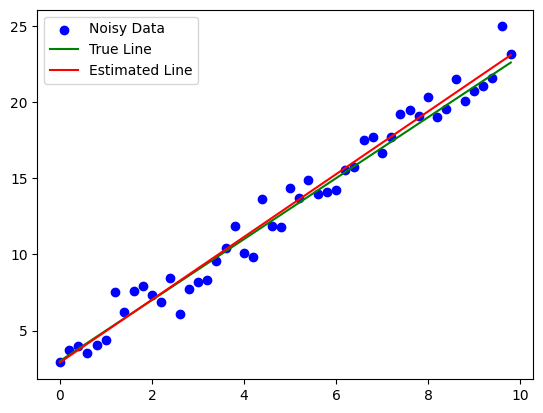

In [21]:
m = 2
b = 3

x = np.arange(0, 10, 0.2)

noise = np.random.normal(0, 1, size=x.shape)
y = m*x + b + noise

X = np.vstack((x, np.ones_like(x))).T  # Concatenating with a column of ones for the intercept term

B = np.linalg.inv(X.T @ X) @ X.T @ y
print(B)

m_est, b_est = B[0], B[1]

plt.scatter(x, y, color='blue', label='Noisy Data')
plt.plot(x, m*x + b, color='green', label='True Line')
plt.plot(x, m_est*x + b_est, color='red', label='Estimated Line')

plt.legend()
plt.show()

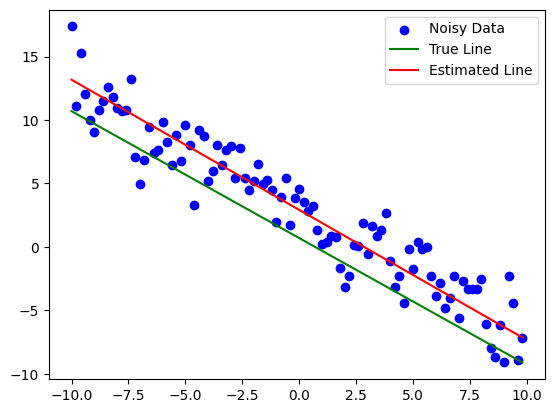

In [28]:
import numpy as np
import matplotlib.pyplot as plt

m = -1
b = 3

x = np.arange(-10, 10, 0.2)

noise = np.random.normal(0, 2, size=x.shape)
y = m*x + b + noise

X = np.hstack((x.reshape(-1, 1), y.reshape(-1, 1)))  # Concatenating x and y
U = X - np.mean(X, axis=0)  # Centering the data

_, _, Vt = np.linalg.svd(U.T @ U)  # SVD decomposition

a, b = Vt[-1, 0], Vt[-1, 1]  # coefficients of the line
d = a*np.mean(X[:, 0]) + b*np.mean(X[:, 1])  # distance from origin

# ax + by = d  => y = (-a/b)x + (d/b)
m_est = -a / b
b_est = d / b

plt.scatter(x, y, color='blue', label='Noisy Data')
plt.plot(x, m*x + b, color='green', label='True Line')
plt.plot(x, m_est*x + b_est, color='red', label='Estimated Line')

plt.legend()
plt.show()

ValueError: x and y must be the same size

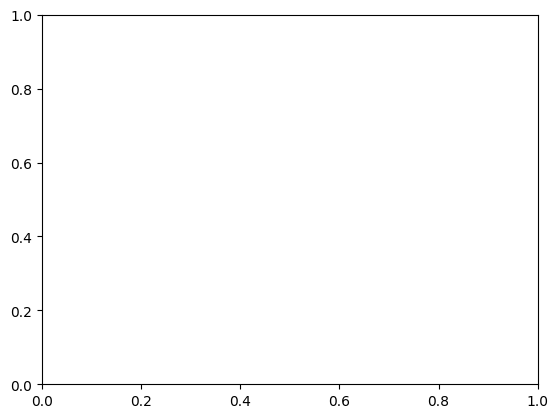

In [27]:
m = -1
b = 3

x = np.arange(-10, 10, 0.2)

noise = np.random.normal(0, 2, size=x.shape)
y = m*x + b + noise

x = np.hstack((x.reshape(-1, 1), np.ones_like(x).reshape(-1, 1)))
U = X - np.mean(X, axis=0)

_,_, Vt = np.linalg.svd(U.T@U)
a, b = Vt.T[-1, 0], Vt.T[-1, 1]
d = a * np.mean(X[:, 0]) + b * np.mean(X[:, 1])

m_est = -a/b
b_est = d/b

plt.scatter(x, y, color='blue', label='Noisy Data')
plt.plot(x, m*x + b, color='green', label='True Line')
plt.plot(x, m_est*x + b_est, color='red', label='Estimated Line')

plt.legend()
plt.show()

**Hough Lines

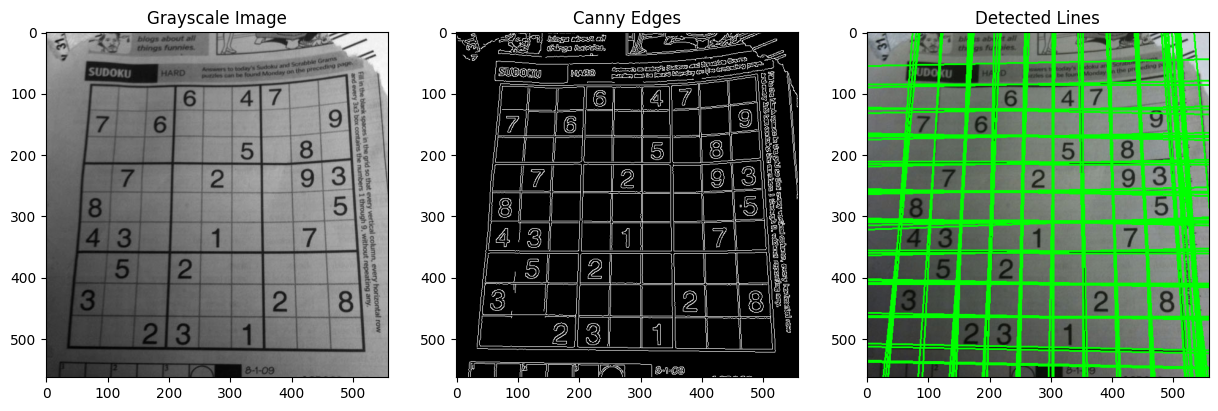

In [32]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

f = cv.imread('sudoku.png', cv.IMREAD_COLOR)
assert f is not None

gray = cv.cvtColor(f, cv.COLOR_BGR2GRAY)
edges = cv.Canny(gray, 50, 100, apertureSize=3)

lines = cv.HoughLines(edges, 1, np.pi/180, 150)

fig, ax = plt.subplots(1, 3, figsize=(15, 10))

ax[0].imshow(gray, cmap='gray')
ax[0].set_title('Grayscale Image')

ax[1].imshow(edges, cmap='gray')
ax[1].set_title('Canny Edges')


# Plotting the detected lines
for line in lines:
    rho, theta = line[0]

    a = np.cos(theta)
    b = np.sin(theta)

    x0 = a * rho
    y0 = b * rho

    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))

    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))

    cv.line(f, (x1, y1), (x2, y2), (0, 255, 0), 2)

ax[2].imshow(cv.cvtColor(f, cv.COLOR_BGR2RGB))
ax[2].set_title('Detected Lines')

plt.show()

Text(0.5, 1.0, 'Detected Circles')

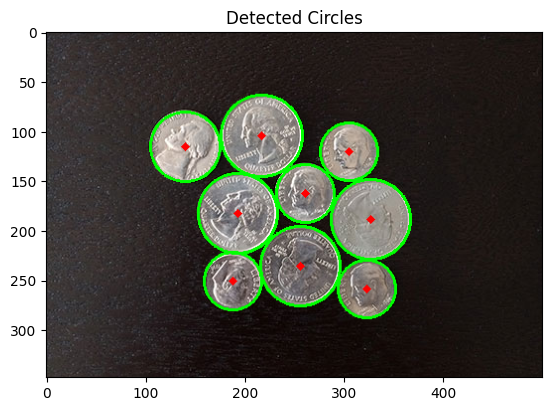

In [34]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

f = cv.imread('coins.jpg', cv.IMREAD_COLOR)
assert f is not None

gray = cv.cvtColor(f, cv.COLOR_BGR2GRAY)
gray = cv.medianBlur(gray, 5)
gray = cv.GaussianBlur(gray, (5, 5), 2)

circles = cv.HoughCircles(gray, cv.HOUGH_GRADIENT, dp=1.2, minDist=40,
                          param1=50, param2=30, minRadius=20, maxRadius=50)

circles = np.uint16(np.around(circles))
for i in circles[0, :]:
    cv.circle(f, (i[0], i[1]), i[2], (0, 255, 0), 2)
    cv.circle(f, (i[0], i[1]), 2, (0, 0, 255), 3)

plt.imshow(cv.cvtColor(f, cv.COLOR_BGR2RGB))
plt.title('Detected Circles')

In [35]:
import cv2 as cv
import numpy as np

im = cv.imread('../../../../Pictures/en3160_images/pic1.png',
               cv.IMREAD_REDUCED_GRAYSCALE_2)

templ = cv.imread('../../../../Pictures/en3160_images/templ.png',
                  cv.IMREAD_REDUCED_GRAYSCALE_2)


# Canny edge detection
im_edges = cv.Canny(im, 50, 250)
templ_edges = cv.Canny(templ, 50, 250)


alg = cv.createGeneralizedHoughGuil()
alg.setTemplate(templ_edges)


# Votes thresholds (to be carefully selected)
alg.setAngleThresh(100000)
alg.setScaleThresh(40000)
alg.setPosThresh(1000)

alg.setAngleStep(1)
alg.setScaleStep(0.1)
alg.setMinScale(0.9)
alg.setMaxScale(1.1)


positions, votes = alg.detect(im_edges)  # Actual detection


out = cv.cvtColor(im, cv.COLOR_BAYER_BG2BGR)

for x, y, scale, orientation in positions[0]:

    halfHeight = templ.shape[0] / 2 * scale
    halfWidth = templ.shape[1] / 2 * scale

    p1 = (int(x - halfWidth), int(y - halfHeight))
    p2 = (int(x + halfWidth), int(y + halfHeight))

    print("x = {}, y = {}, scale = {}, orientation = {}, p1 = {}, p2 = {}"
          .format(x, y, scale, orientation, p1, p2))

    cv.rectangle(out, p1, p2, (0, 0, 255))

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\deriv.cpp:341: error: (-215:Assertion failed) !_src.empty() in function 'cv::Sobel'
